In [3]:
!pip install xgboost==1.7.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 2.2 MB/s  0:01:02m0:00:0100:02
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, precision_recall_curve

# 1. Load the Clinical Matrix
print("[*] Loading Clinical Data...")
data_path = "/workspace/data/processed/physionet_pool/physionet_clinical_24h_clean.csv"
df = pd.read_csv(data_path, index_col=0)

# Separate features (X) and the target label (y)
X = df.drop(columns=['Sepsis_Outcome'])
y = df['Sepsis_Outcome']

# 2. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"[+] Training Set: {X_train.shape[0]} patients")
print(f"[+] Testing Set: {X_test.shape[0]} patients")

# 3. Calculate Class Imbalance Weight
survivors_count = (y_train == 0).sum()
sepsis_count = (y_train == 1).sum()
imbalance_ratio = survivors_count / sepsis_count
print(f"[+] Imbalance Ratio (Non-Sepsis to Sepsis): {imbalance_ratio:.2f}")

# 4. Train the XGBoost Model
print("\n[*] Training the 'ICU Doctor' Model...")
# Notice we don't need to fill NaNs! XGBoost handles them natively.
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,            # Slightly deeper than GEO because we have way more data
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1               # Uses all your CPU cores to train faster!
)

model.fit(X_train, y_train)
print("[+] Training Complete!")

# 5. Evaluate and find the Optimal Threshold
print("\n[*] Evaluating on the Test Set...")
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

# Find the best threshold for F1 Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

# Apply the optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\n==============================")
print(f"      ICU DOCTOR RESULTS      ")
print(f"==============================")
print(f"ROC-AUC Score:     {auc_score:.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"==============================\n")
print("Detailed Clinical Report (Class 1 = Sepsis):")
print(classification_report(y_test, y_pred_optimal))

[*] Loading Clinical Data...
[+] Training Set: 24528 patients
[+] Testing Set: 6133 patients
[+] Imbalance Ratio (Non-Sepsis to Sepsis): 15.63

[*] Training the 'ICU Doctor' Model...
[+] Training Complete!

[*] Evaluating on the Test Set...

      ICU DOCTOR RESULTS      
ROC-AUC Score:     0.7319
Optimal Threshold: 0.4440

Detailed Clinical Report (Class 1 = Sepsis):
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      5764
           1       0.18      0.43      0.25       369

    accuracy                           0.85      6133
   macro avg       0.57      0.65      0.58      6133
weighted avg       0.91      0.85      0.87      6133



[*] Initializing SHAP Explainer...
[*] Sampling 1000 patients from the Vault for explainability...
[*] Calculating SHAP values (calculating game-theory marginal contributions)...

[+] SHAP values calculated! Generating and saving Summary Plot...
[+] High-resolution plot successfully saved to: /workspace/data/processed/physionet_pool/icu_doctor_shap_summary.png


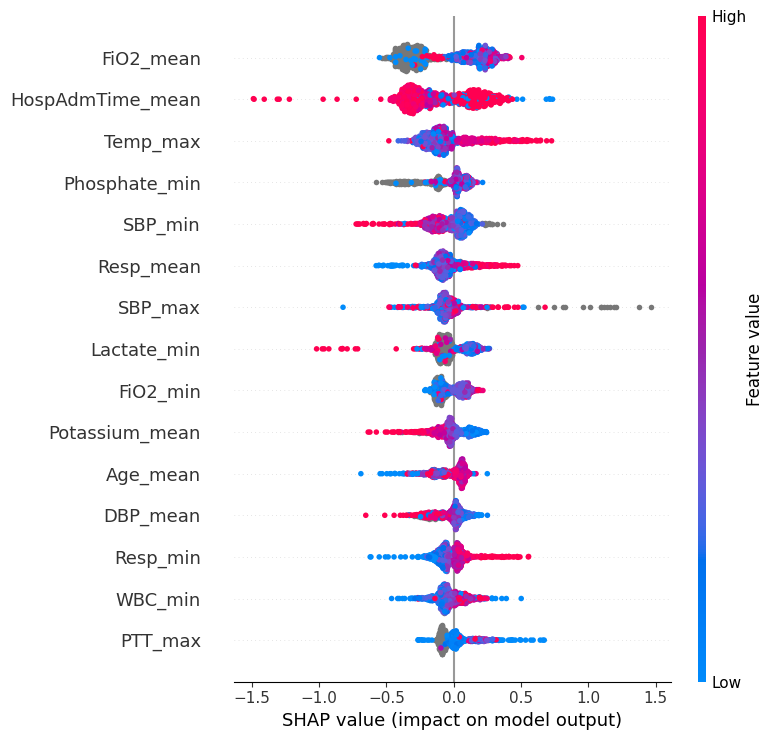

In [5]:
import shap
import matplotlib.pyplot as plt
import os

print("[*] Initializing SHAP Explainer...")
# TreeExplainer is specifically optimized for XGBoost
explainer = shap.TreeExplainer(model)

print("[*] Sampling 1000 patients from the Vault for explainability...")
X_test_sample = X_test.sample(1000, random_state=42)

print("[*] Calculating SHAP values (calculating game-theory marginal contributions)...")
shap_values = explainer.shap_values(X_test_sample)

print("\n[+] SHAP values calculated! Generating and saving Summary Plot...")
plt.figure(figsize=(10, 8))

# THE MAGIC FIX: show=False prevents SHAP from deleting the plot before we save it
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)

# Define where you want to save the high-res image
output_path = "/workspace/data/processed/physionet_pool/icu_doctor_shap_summary.png"

# Save the figure. 
# dpi=300 makes it publication-quality (crisp text). 
# bbox_inches='tight' ensures the long variable names don't get cut off the edge.
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"[+] High-resolution plot successfully saved to: {output_path}")

# Finally, display it in your Jupyter notebook
plt.show()